In [1]:
import sys

In [2]:
sys.path.append('../')

In [3]:
import my_functions

In [4]:
from sklearn.datasets import make_blobs

In [5]:
from imblearn.over_sampling import RandomOverSampler

In [6]:
import imblearn.over_sampling

In [7]:
dir(imblearn.over_sampling)

['ADASYN',
 'BorderlineSMOTE',
 'KMeansSMOTE',
 'RandomOverSampler',
 'SMOTE',
 'SMOTEN',
 'SMOTENC',
 'SVMSMOTE',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adasyn',
 '_random_over_sampler',
 '_smote',
 'base']

In [8]:
?make_blobs

Signature:
make_blobs(
    n_samples=100,
    n_features=2,
    *,
    centers=None,
    cluster_std=1.0,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=None,
    return_centers=False,
)
Docstring:
Generate isotropic Gaussian blobs for clustering.

Read more in the :ref:`User Guide <sample_generators>`.

Parameters
----------
n_samples : int or array-like, default=100
    If int, it is the total number of points equally divided among
    clusters.
    If array-like, each element of the sequence indicates
    the number of samples per cluster.

    .. versionchanged:: v0.20
        one can now pass an array-like to the ``n_samples`` parameter

n_features : int, default=2
    The number of features for each sample.

centers : int or array-like of shape (n_centers, n_features), default=None
    The number of centers to generate, or the fixed center locations.
    If n_samples is an int and centers is None, 3 centers are generated.
    If n_samples is array-like, centers 

# Creating the data

In [9]:
blobs_random_seed = 42
centers = [(0,0), (5,5)]
cluster_std = 1.5
num_features_for_samples=2
num_samples_total = 1600

In [15]:
X,y = make_blobs(
    n_samples=num_samples_total,
    n_features=num_features_for_samples,
    centers=centers,
    cluster_std=cluster_std,
    random_state=0
)

In [17]:
X = pd.DataFrame(X, columns=['varA', 'varB'])
y = pd.Series(y)

In [37]:
#Creating an imbalanced Xset
#Make blobs create same number of obs per class
#we need to downsample manually

X = pd.concat([X[y==0], X[y==1].sample(200, random_state=42)],axis=0)

y = y.loc[X.index]

/tmp/ipykernel_269437/2787582148.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X = pd.concat([X[y==0], X[y==1].sample(200, random_state=42)],axis=0)
/tmp/ipykernel_269437/2787582148.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X = pd.concat([X[y==0], X[y==1].sample(200, random_state=42)],axis=0)


In [38]:
X.shape, y.shape

((1000, 2), (1000,))

In [42]:
sum(X.index == y.index)

np.int64(1000)

In [40]:
y.index

Index([   0,    2,    3,    4,    5,    7,    8,    9,   10,   13,
       ...
        792, 1104, 1316,  875,  384,  721,  658,  560, 1166,  200],
      dtype='int64', length=1000)

In [35]:
X.shape

(1000, 2)

In [31]:
X[y==1].index

Index([   1,    6,   11,   12,   15,   17,   19,   22,   23,   26,
       ...
       1583, 1584, 1585, 1588, 1591, 1592, 1593, 1594, 1597, 1598],
      dtype='int64', length=800)

In [32]:
X[y==1].sample(200).index

Index([1310,  159,  639,  363,  879, 1593,  125,  814,  466, 1192,
       ...
         78, 1103,  321,  406,  563, 1353,   15,  322,  415,  221],
      dtype='int64', length=200)

In [20]:
test = pd.concat([X,y], axis=1)
test.columns = ['varA', 'varB', 'y']
test

,varA,varB,y
0,-3.9888,0.9095,0
1,7.5711,3.8481,1
2,1.1279,0.8445,0
3,-2.4486,-0.1007,0
4,-1.0936,0.2948,0
...,...,...,...
1595,1.1532,-0.6320,0
1596,-0.2154,-0.5730,0
1597,5.8248,5.0013,1
1598,8.2297,5.7025,1


In [22]:
test[y == 0]

,varA,varB,y
0,-3.9888,0.9095,0
2,1.1279,0.8445,0
3,-2.4486,-0.1007,0
4,-1.0936,0.2948,0
5,0.2990,-0.0759,0
...,...,...,...
1589,-0.1722,0.4631,0
1590,1.3429,2.0624,0
1595,1.1532,-0.6320,0
1596,-0.2154,-0.5730,0


In [23]:
test[y==1]

,varA,varB,y
1,7.5711,3.8481,1
6,3.6388,4.7114,1
11,3.5511,3.9135,1
12,2.9452,6.1692,1
15,4.8528,3.6701,1
...,...,...,...
1592,4.8981,8.5403,1
1593,4.9008,4.3663,1
1594,4.1483,4.1133,1
1597,5.8248,5.0013,1


In [25]:
test[test.y == 0]

,varA,varB,y
0,-3.9888,0.9095,0
2,1.1279,0.8445,0
3,-2.4486,-0.1007,0
4,-1.0936,0.2948,0
5,0.2990,-0.0759,0
...,...,...,...
1589,-0.1722,0.4631,0
1590,1.3429,2.0624,0
1595,1.1532,-0.6320,0
1596,-0.2154,-0.5730,0


In [27]:
dir(X[y==1])

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__arrow_c_stream__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__dataframe__',
 '__dataframe_consortium_standard__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__or__',
 '__pandas_priority__',
 '__pos__',
 '__pow__',
 '__r

In [28]:
help(X[:].sample)

Help on method sample in module pandas.core.generic:

sample(n: 'int | None' = None, frac: 'float | None' = None, replace: 'bool_t' = False, weights=None, random_state: 'RandomState | None' = None, axis: 'Axis | None' = None, ignore_index: 'bool_t' = False) -> 'Self' method of pandas.core.frame.DataFrame instance
    Return a random sample of items from an axis of object.
    
    You can use `random_state` for reproducibility.
    
    Parameters
    ----------
    n : int, optional
        Number of items from axis to return. Cannot be used with `frac`.
        Default = 1 if `frac` = None.
    frac : float, optional
        Fraction of axis items to return. Cannot be used with `n`.
    replace : bool, default False
        Allow or disallow sampling of the same row more than once.
    weights : str or ndarray-like, optional
        Default 'None' results in equal probability weighting.
        If passed a Series, will align with target object on index. Index
        values in weight

In [43]:
X.head()

,varA,varB
0,-3.9888,0.9095
2,1.1279,0.8445
3,-2.4486,-0.1007
4,-1.0936,0.2948
5,0.2990,-0.0759


In [ ]:
y.

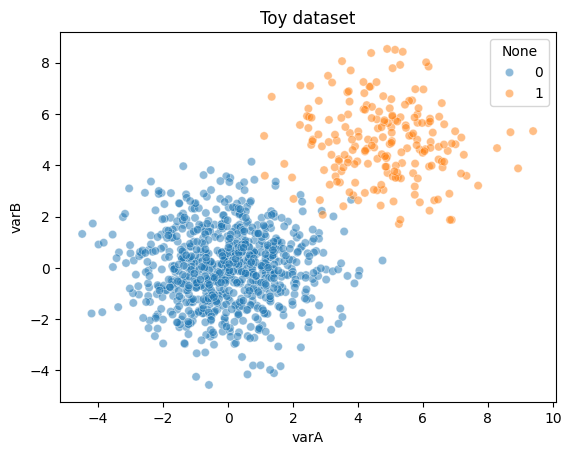

In [45]:
sns.scatterplot(
    data=X, x='varA', y='varB', hue=y, alpha=0.5
)
plt.title('Toy dataset')
plt.show()

# Random Over sampling

In [46]:
import imblearn.over_sampling

In [47]:
for item in dir(imblearn.over_sampling):
    if 'Random' in item:
        print(item)

RandomOverSampler


In [48]:
from imblearn.over_sampling import RandomOverSampler

In [49]:
?RandomOverSampler

Init signature:
RandomOverSampler(
    *,
    sampling_strategy='auto',
    random_state=None,
    shrinkage=None,
)
Docstring:     
Class to perform random over-sampling.

Object to over-sample the minority class(es) by picking samples at random
with replacement. The bootstrap can be generated in a smoothed manner.

Read more in the :ref:`User Guide <random_over_sampler>`.

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

        .. warning::
           ``float`` is only avail

In [51]:
ros = RandomOverSampler(
    sampling_strategy='auto',
    random_state=0,
)

X_res, y_res = ros.fit_resample(X,y)

In [52]:
X.shape, X_res.shape

((1000, 2), (1600, 2))

In [53]:
y.value_counts()

0    800
1    200
Name: count, dtype: int64

In [54]:
y_res.value_counts()

0    800
1    800
Name: count, dtype: int64

In [55]:
for item in dir(my_functions):
    if 'plot' in item:
        print(item)

Scatterplot


In [56]:
from my_functions import Scatterplot

In [57]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

>>>Scatterplot(X, y, X_resampled, y_resampled)
File:      ~/Udemy/Udemy/machine_learning_imbalanced_data/my_functions.py
Type:      function

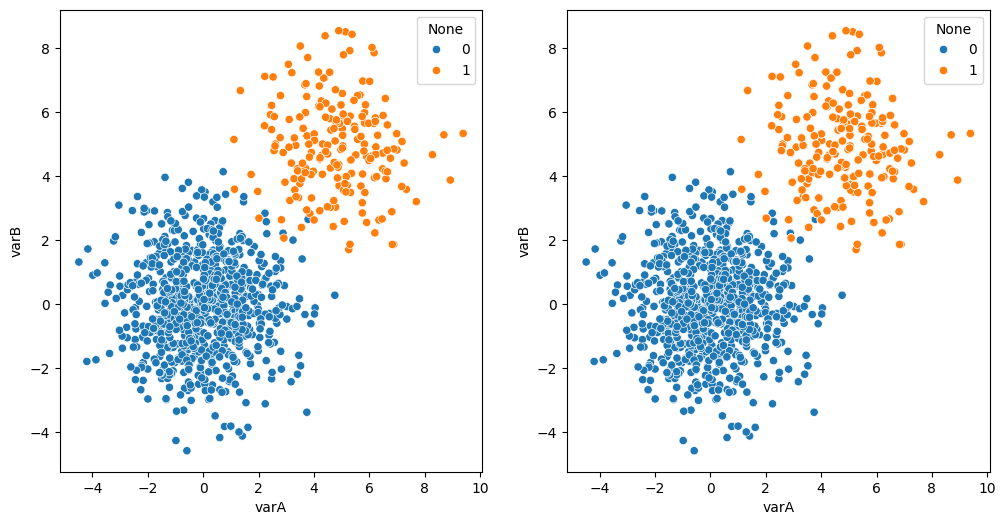

In [58]:
Scatterplot(X, y, X_res, y_res)

In [61]:
def Scatterplot(data1, class1, data2, class2):
    '''
    Plot 2 Scatterplots.
    1 Row and 2 columns, given the 2 provided datasets
    Ex:

    >>>Scatterplot(X, y, X_resampled, y_resampled)


    '''
    
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    sns.scatterplot(data=data1, x=data1.columns[0], y=data1.columns[1], hue=class1, alpha=0.5)

    plt.subplot(122)
    sns.scatterplot(data=data2, x=data2.columns[0], y=data2.columns[1], palette='viridis', hue=class2, alpha=0.5)


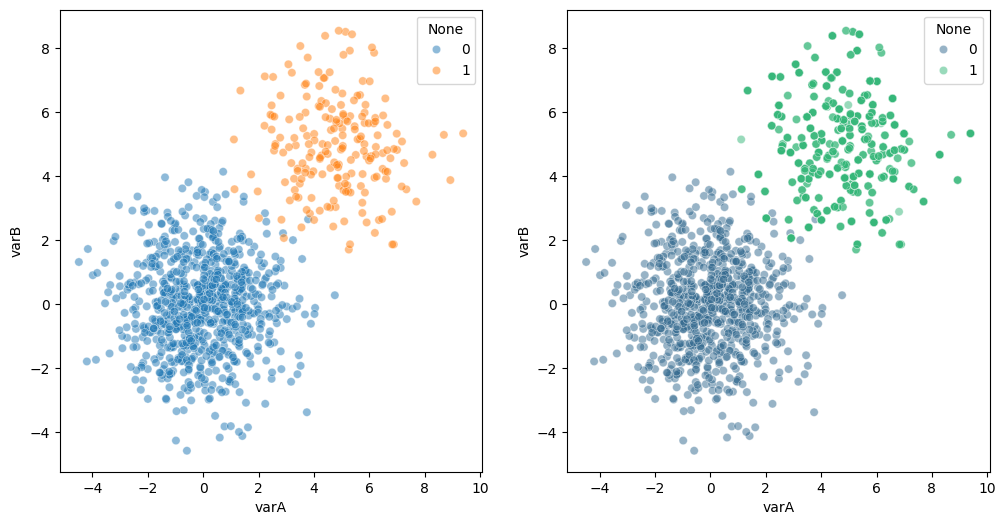

In [62]:
Scatterplot(X, y, X_res, y_res)

# Multiclass

In [63]:
?make_blobs

Signature:
make_blobs(
    n_samples=100,
    n_features=2,
    *,
    centers=None,
    cluster_std=1.0,
    center_box=(-10.0, 10.0),
    shuffle=True,
    random_state=None,
    return_centers=False,
)
Docstring:
Generate isotropic Gaussian blobs for clustering.

Read more in the :ref:`User Guide <sample_generators>`.

Parameters
----------
n_samples : int or array-like, default=100
    If int, it is the total number of points equally divided among
    clusters.
    If array-like, each element of the sequence indicates
    the number of samples per cluster.

    .. versionchanged:: v0.20
        one can now pass an array-like to the ``n_samples`` parameter

n_features : int, default=2
    The number of features for each sample.

centers : int or array-like of shape (n_centers, n_features), default=None
    The number of centers to generate, or the fixed center locations.
    If n_samples is an int and centers is None, 3 centers are generated.
    If n_samples is array-like, centers 

In [64]:
blobs_random_seed = 42
centers = [(0,0), (5,5), [-1,5]]
cluster_std = 1.5
num_features_for_samples=2
num_samples_total = 1600

In [67]:
X, y = make_blobs(
    n_samples=num_samples_total,
    n_features=num_features_for_samples,
    centers=centers,
    cluster_std=cluster_std,
    random_state=blobs_random_seed,
)


In [68]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [69]:
X = pd.DataFrame(X, columns=['varA', 'varB'])
y = pd.Series(y)

In [70]:
X.shape

(1600, 2)

<Axes: xlabel='varA', ylabel='varB'>

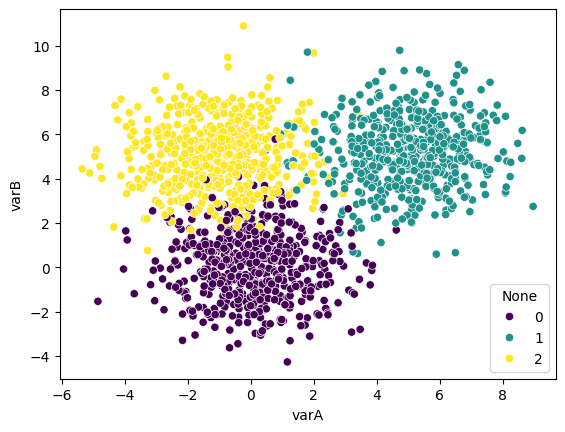

In [73]:
sns.scatterplot(data=X, x='varA', y='varB', hue=y, palette='viridis')

In [75]:
data1 = X[y==0]


In [78]:
data2 = X[y==1].sample(100, random_state=42)

In [79]:
data3 = X[y==2].sample(100, random_state=42)

In [81]:
X = pd.concat([data1, data2, data3], axis=0)

In [82]:
X.shape, y.shape

((734, 2), (1600,))

In [83]:
y = y.loc[X.index]

In [84]:
X.shape, y.shape

((734, 2), (734,))

/tmp/ipykernel_269437/1167303369.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


<Axes: xlabel='varA', ylabel='varB'>

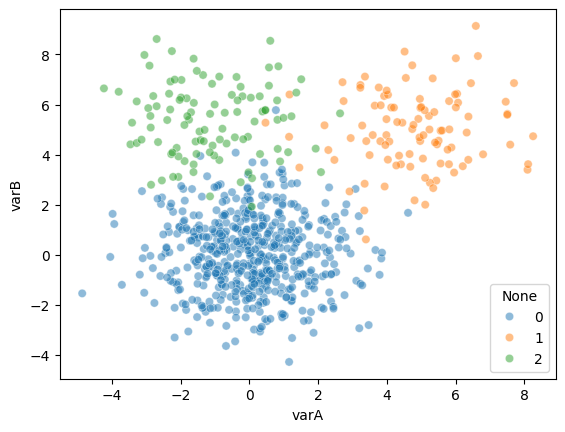

In [88]:
sns.scatterplot(
    data = X, x='varA', y='varB', hue=y, alpha=0.5, palette=sns.color_palette("tab10")
)

In [89]:
y.value_counts()

0    534
1    100
2    100
Name: count, dtype: int64

# Oversampling

In [92]:
from imblearn.over_sampling import RandomOverSampler

In [90]:
for item in dir(imblearn.over_sampling):
    if 'Random' in item:
        print(item)

RandomOverSampler


In [93]:
?RandomOverSampler

Init signature:
RandomOverSampler(
    *,
    sampling_strategy='auto',
    random_state=None,
    shrinkage=None,
)
Docstring:     
Class to perform random over-sampling.

Object to over-sample the minority class(es) by picking samples at random
with replacement. The bootstrap can be generated in a smoothed manner.

Read more in the :ref:`User Guide <random_over_sampler>`.

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

        .. warning::
           ``float`` is only avail

In [94]:
ros = RandomOverSampler(
    sampling_strategy='auto',
    random_state=0,
)

X_res, y_res = ros.fit_resample(X, y)

In [95]:
?Scatterplot

Signature: Scatterplot(data1, class1, data2, class2)
Docstring:
Plot 2 Scatterplots.
1 Row and 2 columns, given the 2 provided datasets
Ex:

>>>Scatterplot(X, y, X_resampled, y_resampled)
File:      /tmp/ipykernel_269437/102247546.py
Type:      function

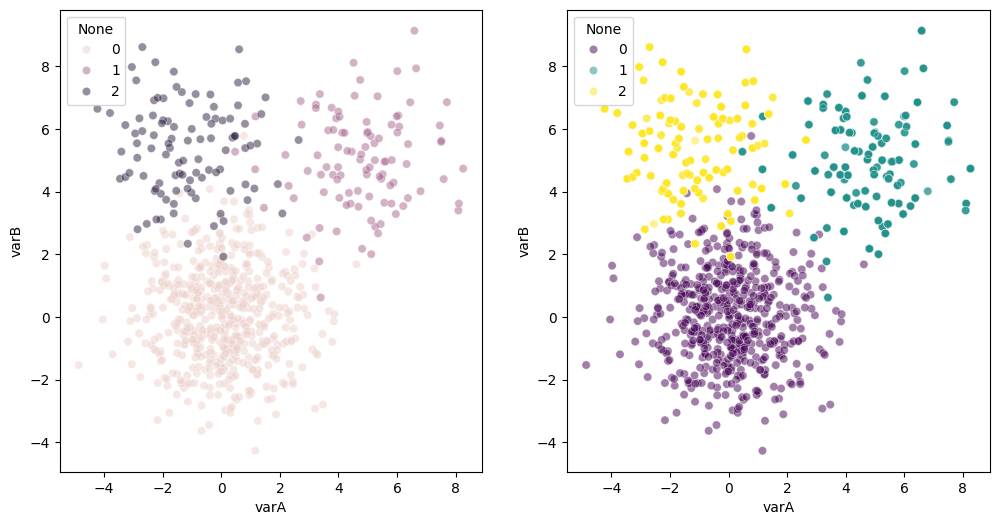

In [96]:
Scatterplot(X, y, X_res, y_res)

In [97]:
y_res.value_counts()

0    534
1    534
2    534
Name: count, dtype: int64

In [98]:
?RandomOverSampler

Init signature:
RandomOverSampler(
    *,
    sampling_strategy='auto',
    random_state=None,
    shrinkage=None,
)
Docstring:     
Class to perform random over-sampling.

Object to over-sample the minority class(es) by picking samples at random
with replacement. The bootstrap can be generated in a smoothed manner.

Read more in the :ref:`User Guide <random_over_sampler>`.

Parameters
----------
sampling_strategy : float, str, dict or callable, default='auto'
    Sampling information to resample the data set.

    - When ``float``, it corresponds to the desired ratio of the number of
      samples in the minority class over the number of samples in the
      majority class after resampling. Therefore, the ratio is expressed as
      :math:`\alpha_{os} = N_{rm} / N_{M}` where :math:`N_{rm}` is the
      number of samples in the minority class after resampling and
      :math:`N_{M}` is the number of samples in the majority class.

        .. warning::
           ``float`` is only avail

In [100]:
ros = RandomOverSampler(
    sampling_strategy={1:500, 2:500},
    random_state=0,
)

X_resampled, y_resampled = ros.fit_resample(X, y)

In [ ]:
# sampling_strategy={1:500, 2:500},
y.value_counts(), y_resampled.value_counts()

(0    534
 1    100
 2    100
 Name: count, dtype: int64,
 0    534
 1    500
 2    500
 Name: count, dtype: int64)

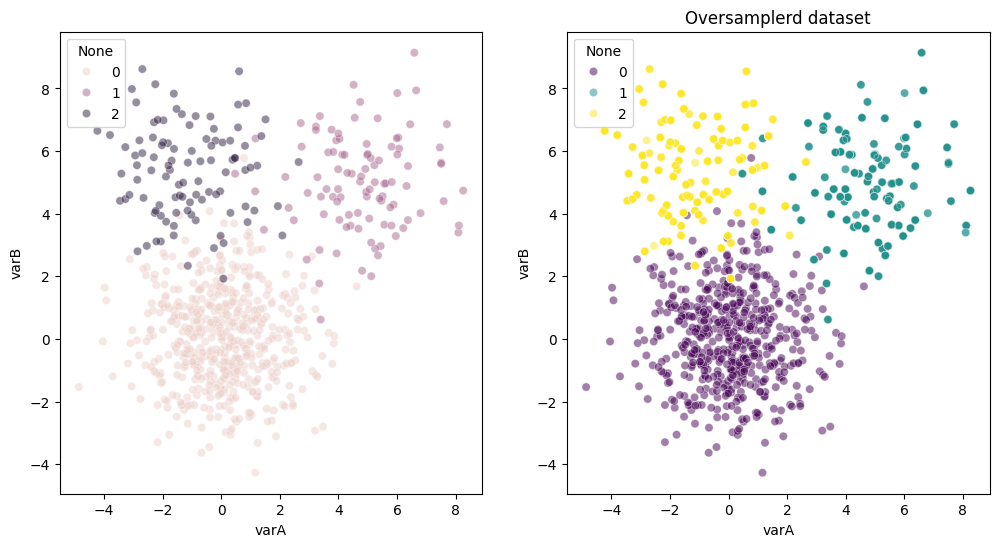

In [105]:
Scatterplot(X, y, X_resampled, y_resampled)
plt.title('Oversamplerd dataset')
plt.show()

In [107]:
y_resampled.value_counts()

0    534
1    500
2    500
Name: count, dtype: int64